In [ ]:
# ==========================================================
# PROYECTO FINAL — SEÑALES BIOMÉDICAS
# Ingeniería Biomédica
#
# Alumnas:Amalia Silis y Vanessa Partida 
# Grupo:3 A
# Fecha:18/05/2026
# ==========================================================

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import random


In [3]:
df = pd.read_csv("proyecto_final_pacientes_biomedicos.csv")


In [4]:
print("PRIMERAS 5 FILAS")
print(df.head())

print("\nDIMENSIONES")
print(df.shape)

print("\nTIPOS DE DATOS")
print(df.dtypes)

print("\nPACIENTES POR GRUPO")
print(df["grupo_clinico"].value_counts())

print("\nVALORES FALTANTES")
print(df.isnull().sum())


PRIMERAS 5 FILAS
  id_paciente  edad sexo    grupo_clinico  fc_lpm  ruido_ecg estado_eeg  \
0        P001    21    F  control_estable      64      0.018   relajado   
1        P002    24    M  control_estable      68      0.020   relajado   
2        P003    27    F  control_estable      72      0.018     alerta   
3        P004    29    M  control_estable      75      0.022     alerta   
4        P005    31    F  control_estable      61      0.015   relajado   

   ruido_eeg  factor_contraccion  pa_sistolica  pa_diastolica  spo2_media  \
0      0.040                0.22           112             72        98.7   
1      0.045                0.28           118             76        98.3   
2      0.040                0.30           120             78        97.9   
3      0.050                0.35           122             80        98.1   
4      0.035                0.18           110             70        99.0   

   duracion_segundos prioridad  \
0                 10      baja   
1

In [5]:
df["pulso_presion"] = (
    df["pa_sistolica"] -
    df["pa_diastolica"]
)

df["hipoxemia"] = (
    df["spo2_media"] < 92
)

df["taquicardia"] = (
    df["fc_lpm"] > 100
)

df["hipertension"] = (
    (df["pa_sistolica"] >= 140) |
    (df["pa_diastolica"] >= 90)
)

print(df.head())

  id_paciente  edad sexo    grupo_clinico  fc_lpm  ruido_ecg estado_eeg  \
0        P001    21    F  control_estable      64      0.018   relajado   
1        P002    24    M  control_estable      68      0.020   relajado   
2        P003    27    F  control_estable      72      0.018     alerta   
3        P004    29    M  control_estable      75      0.022     alerta   
4        P005    31    F  control_estable      61      0.015   relajado   

   ruido_eeg  factor_contraccion  pa_sistolica  pa_diastolica  spo2_media  \
0      0.040                0.22           112             72        98.7   
1      0.045                0.28           118             76        98.3   
2      0.040                0.30           120             78        97.9   
3      0.050                0.35           122             80        98.1   
4      0.035                0.18           110             70        99.0   

   duracion_segundos prioridad  \
0                 10      baja   
1                 

In [6]:
print("PACIENTES CON HIPOXEMIA")
print(df["hipoxemia"].sum())

print("\nPACIENTES CON TAQUICARDIA")
print(df["taquicardia"].sum())

print("\nPROMEDIO DE PRESIÓN SISTÓLICA")
print(
    df.groupby("grupo_clinico")["pa_sistolica"]
    .mean()
    .sort_values(ascending=False)
)

PACIENTES CON HIPOXEMIA
5

PACIENTES CON TAQUICARDIA
10

PROMEDIO DE PRESIÓN SISTÓLICA
grupo_clinico
hipertension          161.333333
taquicardia_estres    136.166667
hipoxemia_fatiga      125.000000
control_estable       117.666667
Name: pa_sistolica, dtype: float64


In [7]:
def gaussiana(x, mu, sigma):

    return math.exp(
        -((x - mu) ** 2) /
        (2 * sigma ** 2)
    )

In [8]:
def ecg_sintetico(t, fc=70, ruido=0.02):

    periodo = 60 / fc

    fase = t % periodo

    onda_p = (
        0.1 *
        gaussiana(fase, 0.1, 0.02)
    )

    complejo_qrs = (
        1.0 *
        gaussiana(fase, 0.2, 0.01)
    )

    onda_t = (
        0.3 *
        gaussiana(fase, 0.4, 0.04)
    )

    ruido_random = random.uniform(
        -ruido,
        ruido
    )

    return (
        onda_p +
        complejo_qrs +
        onda_t +
        ruido_random
    )

In [9]:
def eeg_sintetico(
    t,
    estado="relajado",
    ruido=0.5
):

    if estado == "relajado":
        frecuencia = 8

    elif estado == "alerta":
        frecuencia = 15

    else:
        frecuencia = 25

    señal = math.sin(
        2 * math.pi * frecuencia * t
    )

    return (
        señal +
        random.uniform(-ruido, ruido)
    )

In [10]:
def nivel_contraccion(t):

    return (
        0.5 +
        0.5 *
        math.sin(
            2 * math.pi * 0.5 * t
        )
    )

In [11]:
def emg_sintetico(
    t,
    contraccion=1
):

    ruido = random.uniform(-1, 1)

    return contraccion * ruido

In [12]:
def presion_arterial(
    t,
    sistolica=120,
    diastolica=80
):

    pulso = gaussiana(
        t % 1,
        0.2,
        0.08
    )

    return (
        diastolica +
        (sistolica - diastolica)
        * pulso
    )

In [13]:
def spo2_ppg(
    t,
    spo2=98
):

    variacion = (
        0.5 *
        math.sin(
            2 * math.pi * 1.2 * t
        )
    )

    return spo2 + variacion

In [14]:
def generar_senales_paciente(fila):

    datos = []

    duracion = int(
        fila["duracion_segundos"]
    )

    for i in range(duracion * 100):

        t = i / 100

        contraccion = min(
            1.0,
            fila["factor_contraccion"] *
            nivel_contraccion(t)
        )

        datos.append({

            "tiempo_s": t,

            "ecg_mV":
            ecg_sintetico(
                t,
                fila["fc_lpm"],
                fila["ruido_ecg"]
            ),

            "eeg_uV":
            eeg_sintetico(
                t,
                fila["estado_eeg"],
                fila["ruido_eeg"]
            ),

            "emg_mV":
            emg_sintetico(
                t,
                contraccion
            ),

            "pa_mmHg":
            presion_arterial(
                t,
                fila["pa_sistolica"],
                fila["pa_diastolica"]
            ),

            "spo2_pct":
            spo2_ppg(
                t,
                fila["spo2_media"]
            )
        })

    return pd.DataFrame(datos)

In [15]:
control = df[
    df["grupo_clinico"] ==
    "control_estable"
].iloc[0]

taquicardia = df[
    df["grupo_clinico"] ==
    "taquicardia_estres"
].iloc[0]

hipertension = df[
    df["grupo_clinico"] ==
    "hipertension"
].iloc[0]

hipoxemia = df[
    df["grupo_clinico"] ==
    "hipoxemia_fatiga"
].iloc[0]

In [16]:
senal_control = generar_senales_paciente(control)

senal_taquicardia = generar_senales_paciente(
    taquicardia
)

senal_hipertension = generar_senales_paciente(
    hipertension
)

senal_hipoxemia = generar_senales_paciente(
    hipoxemia
)

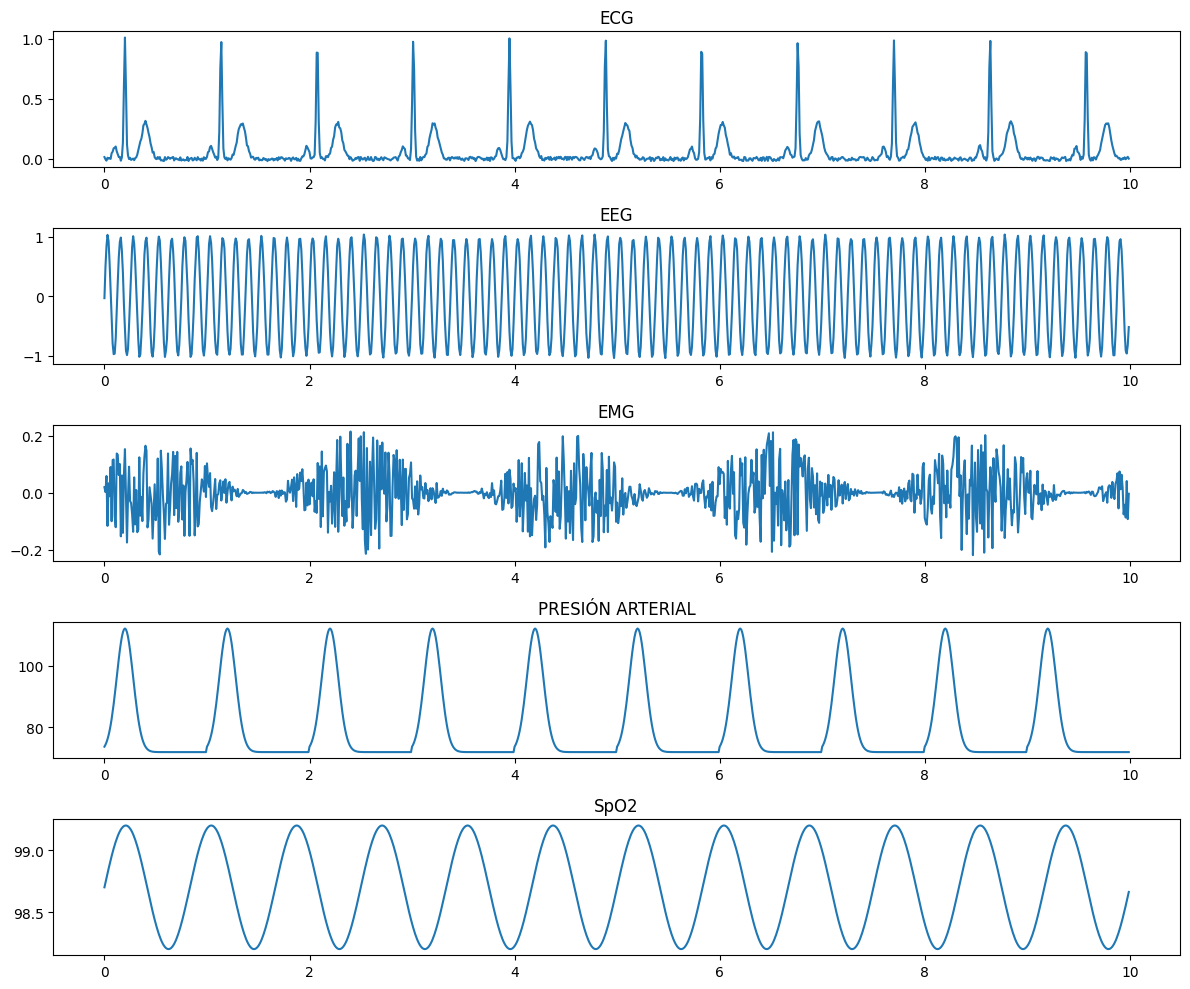

In [18]:
fig, axs = plt.subplots(
    5,
    1,
    figsize=(12,10)
)

axs[0].plot(
    senal_control["tiempo_s"],
    senal_control["ecg_mV"]
)
axs[0].set_title("ECG")

axs[1].plot(
    senal_control["tiempo_s"],
    senal_control["eeg_uV"]
)
axs[1].set_title("EEG")

axs[2].plot(
    senal_control["tiempo_s"],
    senal_control["emg_mV"]
)
axs[2].set_title("EMG")

axs[3].plot(
    senal_control["tiempo_s"],
    senal_control["pa_mmHg"]
)
axs[3].set_title("PRESIÓN ARTERIAL")

axs[4].plot(
    senal_control["tiempo_s"],
    senal_control["spo2_pct"]
)
axs[4].set_title("SpO2")

plt.tight_layout()
plt.show()

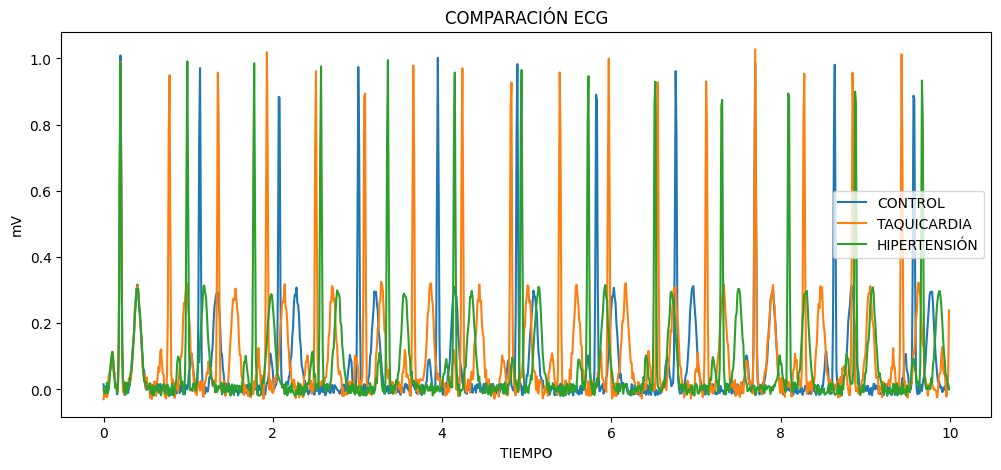

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    senal_control["tiempo_s"],
    senal_control["ecg_mV"],
    label="CONTROL"
)

plt.plot(
    senal_taquicardia["tiempo_s"],
    senal_taquicardia["ecg_mV"],
    label="TAQUICARDIA"
)

plt.plot(
    senal_hipertension["tiempo_s"],
    senal_hipertension["ecg_mV"],
    label="HIPERTENSIÓN"
)

plt.legend()

plt.title("COMPARACIÓN ECG")

plt.xlabel("TIEMPO")

plt.ylabel("mV")

plt.show()

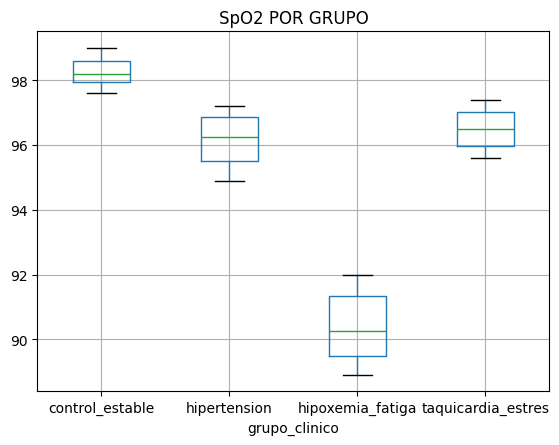

In [20]:
df.boxplot(
    column="spo2_media",
    by="grupo_clinico"
)

plt.title("SpO2 POR GRUPO")

plt.suptitle("")

plt.show()

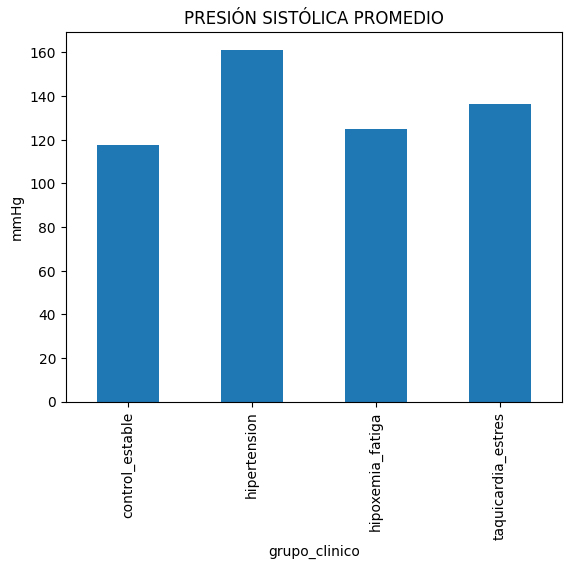

In [21]:
df.groupby(
    "grupo_clinico"
)["pa_sistolica"].mean().plot(
    kind="bar"
)

plt.title(
    "PRESIÓN SISTÓLICA PROMEDIO"
)

plt.ylabel("mmHg")

plt.show()

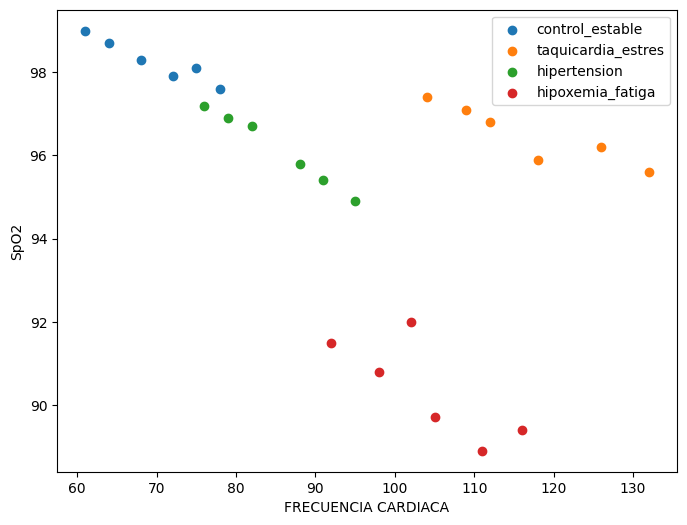

In [22]:
plt.figure(figsize=(8,6))

for grupo in df[
    "grupo_clinico"
].unique():

    temp = df[
        df["grupo_clinico"] == grupo
    ]

    plt.scatter(
        temp["fc_lpm"],
        temp["spo2_media"],
        label=grupo
    )

plt.xlabel(
    "FRECUENCIA CARDIACA"
)

plt.ylabel("SpO2")

plt.legend()

plt.show()

In [23]:
resumen = df.groupby(
    "grupo_clinico"
).agg({

    "fc_lpm":"mean",

    "spo2_media":"mean",

    "pa_sistolica":"mean",

    "pa_diastolica":"mean"

})

print(resumen)

                        fc_lpm  spo2_media  pa_sistolica  pa_diastolica
grupo_clinico                                                          
control_estable      69.666667   98.266667    117.666667      76.333333
hipertension         85.166667   96.150000    161.333333     101.000000
hipoxemia_fatiga    104.000000   90.383333    125.000000      81.000000
taquicardia_estres  116.833333   96.500000    136.166667      87.000000


In [24]:
print("""
""")


1. El grupo con mayor riesgo cardiovascular
es hipertensión debido a la presión arterial
elevada.

2. En taquicardia los complejos ECG aparecen
más juntos porque el corazón late más rápido.

3. El EEG relajado presenta ondas lentas,
mientras que alerta y concentrado muestran
frecuencias mayores.

4. Una frecuencia cardiaca elevada puede
relacionarse con menor oxigenación.

5. Los datos simulados no representan
completamente el comportamiento real
de un paciente.

